In [1]:
# Step 0 — Environment Setup
import rasterio
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
import pandas as pd
from rasterio.warp import calculate_default_transform, reproject, Resampling
from scipy.ndimage import gaussian_filter
from scipy import stats

print("📦 Library Versions:")
print(f"  rasterio  : {rasterio.__version__}")
print(f"  numpy     : {np.__version__}")
print(f"  matplotlib: {matplotlib.__version__}")
print(f"  scipy     : {scipy.__version__}")
print(f"  seaborn   : {sns.__version__}")
print(f"  pandas    : {pd.__version__}")
print("\n✅ Environment ready!")

📦 Library Versions:
  rasterio  : 1.5.0
  numpy     : 2.1.3
  matplotlib: 3.10.0
  scipy     : 1.15.3
  seaborn   : 0.13.2
  pandas    : 2.2.3

✅ Environment ready!


In [2]:
# Step 1 — Raster Loading and Inspection

def inspect_raster(path, name):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        
        # Reemplazar NoData
        if nodata is not None:
            valid_mask = data != nodata
        else:
            valid_mask = np.ones(data.shape, dtype=bool)
        
        valid_pixels = data[valid_mask]
        
        print(f"\n{'='*50}")
        print(f"📂 {name}")
        print(f"{'='*50}")
        print(f"  CRS            : {src.crs}")
        print(f"  Shape          : {src.height} x {src.width} (height x width)")
        print(f"  Band count     : {src.count}")
        print(f"  NoData value   : {nodata}")
        print(f"  Data type      : {src.dtypes[0]}")
        print(f"  Bounding box   : {src.bounds}")
        print(f"  Pixel res (deg): {src.res}")
        print(f"  Pixel res (km) : ~{src.res[0]*111:.3f} x {src.res[1]*111:.3f} km")
        print(f"  Valid pixels   : {valid_pixels.size:,}")
        print(f"  Value range    : [{valid_pixels.min():.4f}, {valid_pixels.max():.4f}]")

# Rutas
VNL_PATH  = "../data/VNL_cusco_2025.tif"
CONN_PATH = "../data/kernel_cobmovil2019_50m.tif"

inspect_raster(VNL_PATH, "VNL Nighttime Lights (NASA)")
inspect_raster(CONN_PATH, "Mobile Coverage Kernel (OSIPTEL)")


📂 VNL Nighttime Lights (NASA)
  CRS            : GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
  Shape          : 1081 x 961 (height x width)
  Band count     : 1
  NoData value   : None
  Data type      : float32
  Bounding box   : BoundingBox(left=-74.00208248534999, bottom=-15.50208405735, right=-69.99791578664998, top=-10.99791735465)
  Pixel res (deg): (0.0041666667, 0.0041666667)
  Pixel res (km) : ~0.463 x 0.463 km
  Valid pixels   : 1,038,841
  Value range    : [-1.5000, 1254.6145]

📂 Mobile Coverage Kernel (OSIPTEL)
  CRS            : PROJCS["WGS_1984_UTM_Zone_19S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],

In [3]:
# Step 2 — Reprojection and Grid Alignment
import os
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

os.makedirs("../output", exist_ok=True)

# --- Leer VNL como referencia de grilla ---
with rasterio.open(VNL_PATH) as src_vnl:
    vnl_crs       = src_vnl.crs
    vnl_transform = src_vnl.transform
    vnl_shape     = (src_vnl.height, src_vnl.width)
    vnl_nodata    = src_vnl.nodata
    vnl_raw       = src_vnl.read(1).astype(float)

# --- Reproyectar CONN de EPSG:32719 → EPSG:4326 ---
with rasterio.open(CONN_PATH) as src_conn:
    conn_nodata = src_conn.nodata  # -3.4e+38
    
    # Calcular transform destino en EPSG:4326
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src_conn.crs,       # CRS origen
        vnl_crs,            # CRS destino (4326)
        src_conn.width,
        src_conn.height,
        *src_conn.bounds
    )
    
    # Array temporal para la reproyección
    conn_reprojected = np.zeros((dst_height, dst_width), dtype=np.float32)
    
    reproject(
        source        = rasterio.band(src_conn, 1),
        destination   = conn_reprojected,
        src_transform = src_conn.transform,
        src_crs       = src_conn.crs,
        dst_transform = dst_transform,
        dst_crs       = vnl_crs,
        resampling    = Resampling.bilinear,
        src_nodata    = conn_nodata,
        dst_nodata    = 0.0
    )

print(f"✅ Reproyección completada")
print(f"   Shape reproyectado : {conn_reprojected.shape}")

# --- Resamplear al grid exacto del VNL ---
conn_aligned = np.zeros(vnl_shape, dtype=np.float32)

with rasterio.open(CONN_PATH) as src_conn:
    reproject(
        source        = rasterio.band(src_conn, 1),
        destination   = conn_aligned,
        src_transform = src_conn.transform,
        src_crs       = src_conn.crs,
        dst_transform = vnl_transform,
        dst_crs       = vnl_crs,
        resampling    = Resampling.bilinear,
        src_nodata    = conn_nodata,
        dst_nodata    = 0.0
    )

print(f"✅ Resampleo completado")
print(f"   Shape VNL          : {vnl_shape}")
print(f"   Shape CONN alineado: {conn_aligned.shape}")
print(f"   ¿Dimensiones iguales? {vnl_shape == conn_aligned.shape}")

✅ Reproyección completada
   Shape reproyectado : (6132, 7905)
✅ Resampleo completado
   Shape VNL          : (1081, 961)
   Shape CONN alineado: (1081, 961)
   ¿Dimensiones iguales? True


In [4]:
# Step 3 — Robust Normalization

def normalize_robust(arr, nodata_val=None, name=""):
    """Normalización por percentiles [2-98], rango [0,1]"""
    data = arr.copy().astype(float)
    
    # Reemplazar negativos y NoData con 0
    if nodata_val is not None:
        data[data == nodata_val] = 0
    data[data < 0] = 0
    
    # Calcular percentiles sobre valores positivos
    valid = data[data > 0]
    if len(valid) == 0:
        print(f"  ⚠️ {name}: sin valores válidos positivos")
        return data
    
    p2  = np.percentile(valid, 2)
    p98 = np.percentile(valid, 98)
    
    # Clipear y normalizar
    data = np.clip(data, p2, p98)
    data = (data - p2) / (p98 - p2)
    data = np.clip(data, 0, 1)
    
    print(f"\n📊 {name}")
    print(f"   Percentil  2 : {p2:.4f}")
    print(f"   Percentil 98 : {p98:.4f}")
    print(f"   Post-norm min: {data.min():.4f}")
    print(f"   Post-norm max: {data.max():.4f}")
    print(f"   Post-norm mean: {data.mean():.4f}")
    print(f"   Post-norm std : {data.std():.4f}")
    
    return data

print("🔄 Normalizando capas...")

vnl_norm  = normalize_robust(vnl_raw,      nodata_val=vnl_nodata,  name="VNL Nighttime Lights")
conn_norm = normalize_robust(conn_aligned,  nodata_val=conn_nodata, name="Mobile Connectivity")

print("\n✅ Normalización completa!")

🔄 Normalizando capas...

📊 VNL Nighttime Lights
   Percentil  2 : 0.2355
   Percentil 98 : 16.6046
   Post-norm min: 0.0000
   Post-norm max: 1.0000
   Post-norm mean: 0.0035
   Post-norm std : 0.0414

📊 Mobile Connectivity
   Percentil  2 : 0.0000
   Percentil 98 : 0.0000
   Post-norm min: 0.0000
   Post-norm max: 1.0000
   Post-norm mean: 0.0142
   Post-norm std : 0.0807

✅ Normalización completa!


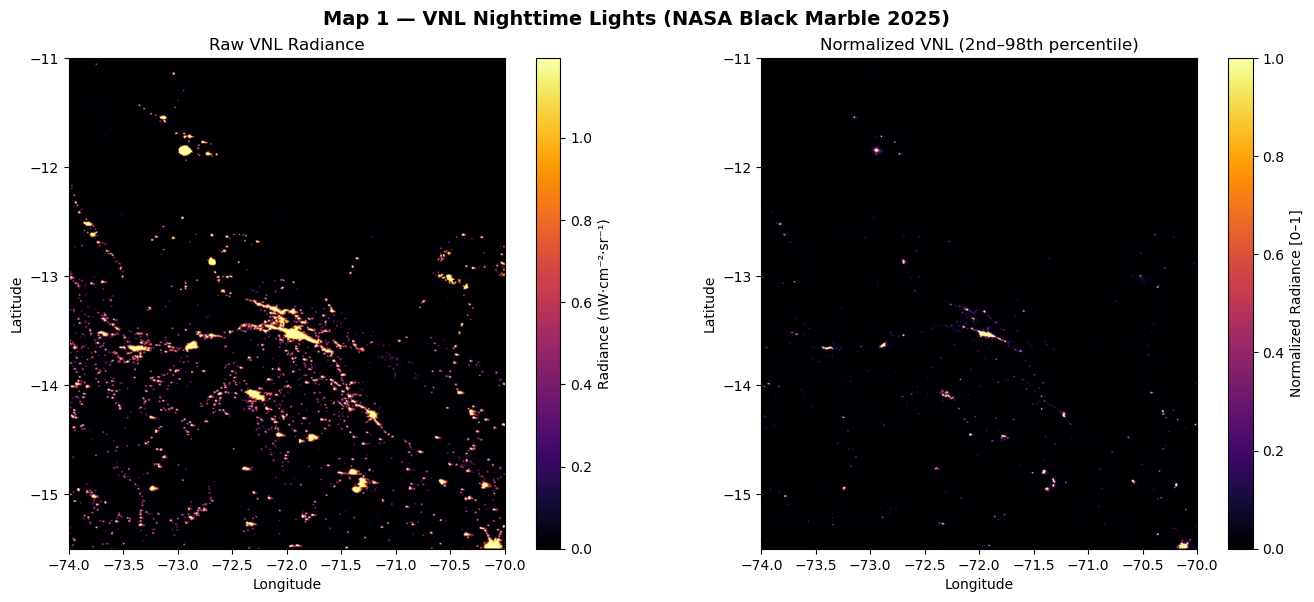


🔍 Observación:
   Las zonas brillantes corresponden a centros urbanos como la ciudad
   del Cusco y capitales de provincia. Las áreas oscuras representan
   zonas rurales y de alta montaña sin actividad humana significativa.


In [5]:
# Step 4 — Map 1: VNL Nighttime Lights

# Extensión geográfica del raster VNL
with rasterio.open(VNL_PATH) as src:
    bounds = src.bounds
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Map 1 — VNL Nighttime Lights (NASA Black Marble 2025)", 
             fontsize=14, fontweight='bold')

# --- Panel izquierdo: VNL crudo ---
ax = axes[0]
vnl_plot = vnl_raw.copy()
vnl_plot[vnl_plot < 0] = 0
im0 = ax.imshow(vnl_plot, cmap='inferno', extent=extent,
                origin='upper', vmin=0, vmax=np.percentile(vnl_plot, 99))
plt.colorbar(im0, ax=ax, label='Radiance (nW·cm⁻²·sr⁻¹)')
ax.set_title('Raw VNL Radiance')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# --- Panel derecho: VNL normalizado ---
ax = axes[1]
im1 = ax.imshow(vnl_norm, cmap='inferno', extent=extent,
                origin='upper', vmin=0, vmax=1)
plt.colorbar(im1, ax=ax, label='Normalized Radiance [0–1]')
ax.set_title('Normalized VNL (2nd–98th percentile)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig("../output/map1_vnl.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Observación:")
print("   Las zonas brillantes corresponden a centros urbanos como la ciudad")
print("   del Cusco y capitales de provincia. Las áreas oscuras representan")
print("   zonas rurales y de alta montaña sin actividad humana significativa.")

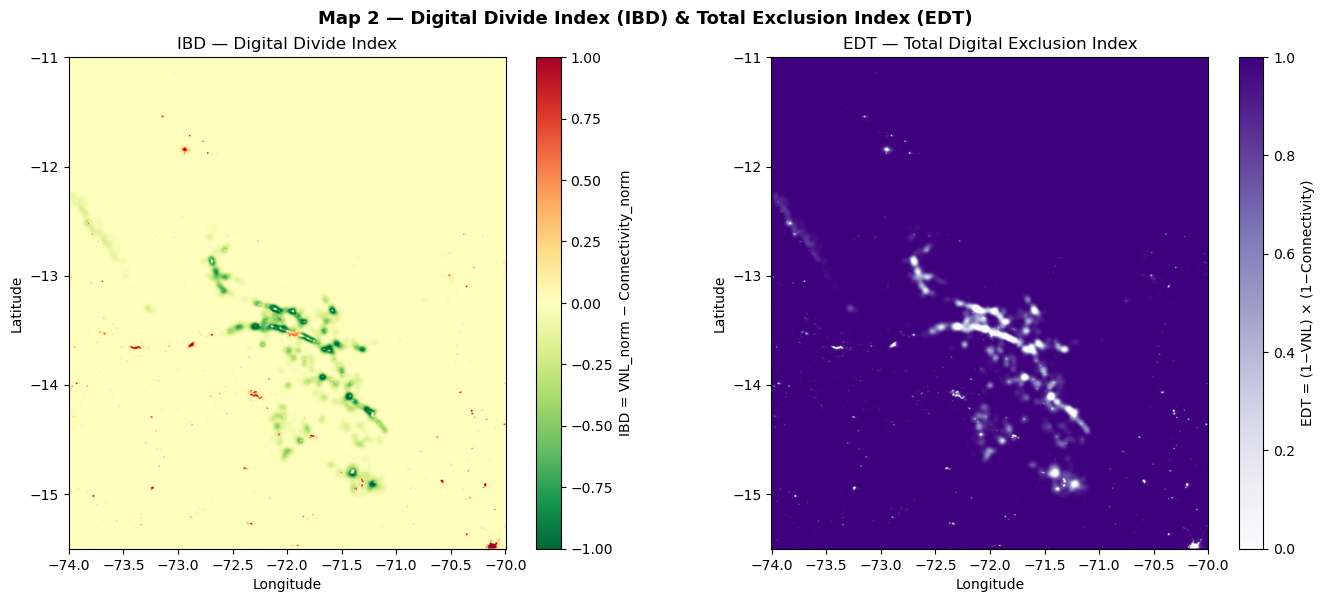


🔍 Interpretación IBD:
   Zonas rojas: alta luminosidad pero baja conectividad → brecha digital activa.
   Zonas verdes: bien conectadas relativamente a su nivel de urbanización.

🔍 Interpretación EDT:
   Zonas púrpuras intensas: sin luz Y sin conectividad → exclusión digital máxima.
   Representan las áreas rurales más vulnerables del territorio cusqueño.


In [6]:
# Step 5 — Map 2: Digital Divide Index (IBD) and Total Exclusion Index (EDT)

# --- Calcular índices ---
IBD = vnl_norm - conn_norm          # rango [-1, 1]
EDT = (1 - vnl_norm) * (1 - conn_norm)  # rango [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Map 2 — Digital Divide Index (IBD) & Total Exclusion Index (EDT)",
             fontsize=13, fontweight='bold')

# --- Panel izquierdo: IBD ---
ax = axes[0]
im0 = ax.imshow(IBD, cmap='RdYlGn_r', extent=extent,
                origin='upper', vmin=-1, vmax=1)
plt.colorbar(im0, ax=ax, label='IBD = VNL_norm − Connectivity_norm')
ax.set_title('IBD — Digital Divide Index')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# --- Panel derecho: EDT ---
ax = axes[1]
im1 = ax.imshow(EDT, cmap='Purples', extent=extent,
                origin='upper', vmin=0, vmax=1)
plt.colorbar(im1, ax=ax, label='EDT = (1−VNL) × (1−Connectivity)')
ax.set_title('EDT — Total Digital Exclusion Index')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig("../output/map2_ibd_edt.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Interpretación IBD:")
print("   Zonas rojas: alta luminosidad pero baja conectividad → brecha digital activa.")
print("   Zonas verdes: bien conectadas relativamente a su nivel de urbanización.")

print("\n🔍 Interpretación EDT:")
print("   Zonas púrpuras intensas: sin luz Y sin conectividad → exclusión digital máxima.")
print("   Representan las áreas rurales más vulnerables del territorio cusqueño.")

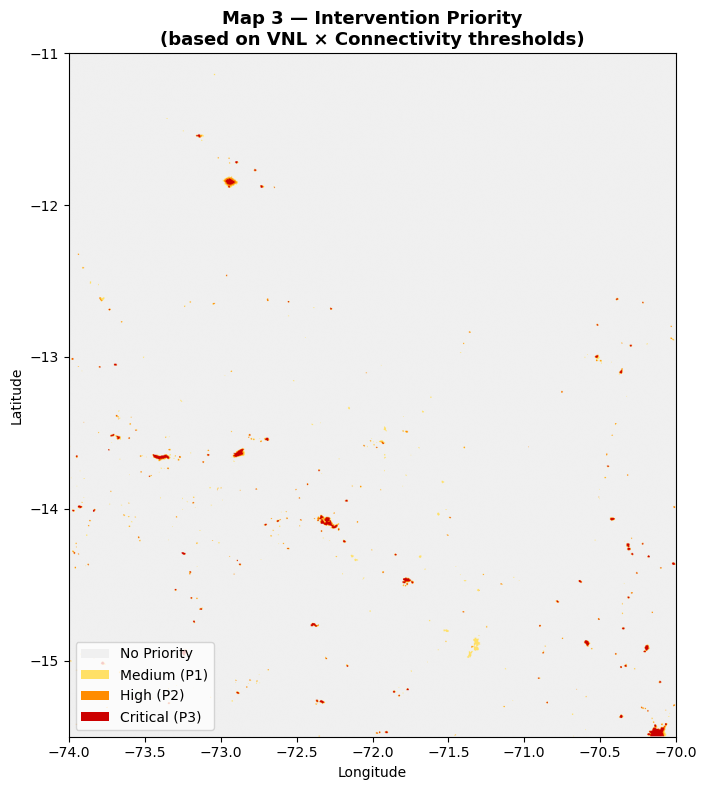


📊 Pixel count por nivel de prioridad:
Nivel                   Píxeles  % del total
--------------------------------------------
No Priority           1,034,415       99.57%
Medium (P1)               1,570        0.15%
High (P2)                 1,267        0.12%
Critical (P3)             1,589        0.15%


In [7]:
# Step 6 — Map 3: Intervention Priority

# --- Clasificar por niveles de prioridad ---
priority = np.zeros(vnl_norm.shape, dtype=np.uint8)

# P1 — Medio: VNL >= 0.10 y Connectivity < 0.25
priority[(vnl_norm >= 0.10) & (conn_norm < 0.25)] = 1

# P2 — Alto: VNL >= 0.15 y Connectivity < 0.15
priority[(vnl_norm >= 0.15) & (conn_norm < 0.15)] = 2

# P3 — Crítico: VNL >= 0.30 y Connectivity < 0.10
priority[(vnl_norm >= 0.30) & (conn_norm < 0.10)] = 3

# --- Mapa ---
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

cmap_priority = ListedColormap(['#f0f0f0', '#ffe066', '#ff8c00', '#cc0000'])
labels = ['No Priority', 'Medium (P1)', 'High (P2)', 'Critical (P3)']
colors = ['#f0f0f0', '#ffe066', '#ff8c00', '#cc0000']

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(priority, cmap=cmap_priority, extent=extent,
               origin='upper', vmin=0, vmax=3)
ax.set_title('Map 3 — Intervention Priority\n(based on VNL × Connectivity thresholds)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

legend_elements = [Patch(facecolor=colors[i], label=labels[i]) for i in range(4)]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig("../output/map3_priority.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Estadísticas por nivel ---
total_pixels = priority.size
print(f"\n📊 Pixel count por nivel de prioridad:")
print(f"{'Nivel':<20} {'Píxeles':>10} {'% del total':>12}")
print("-" * 44)
for i, label in enumerate(labels):
    count = np.sum(priority == i)
    pct   = count / total_pixels * 100
    print(f"{label:<20} {count:>10,} {pct:>11.2f}%")

📊 Risk thresholds:
   75th percentile: 1.0000
   90th percentile: 1.0000


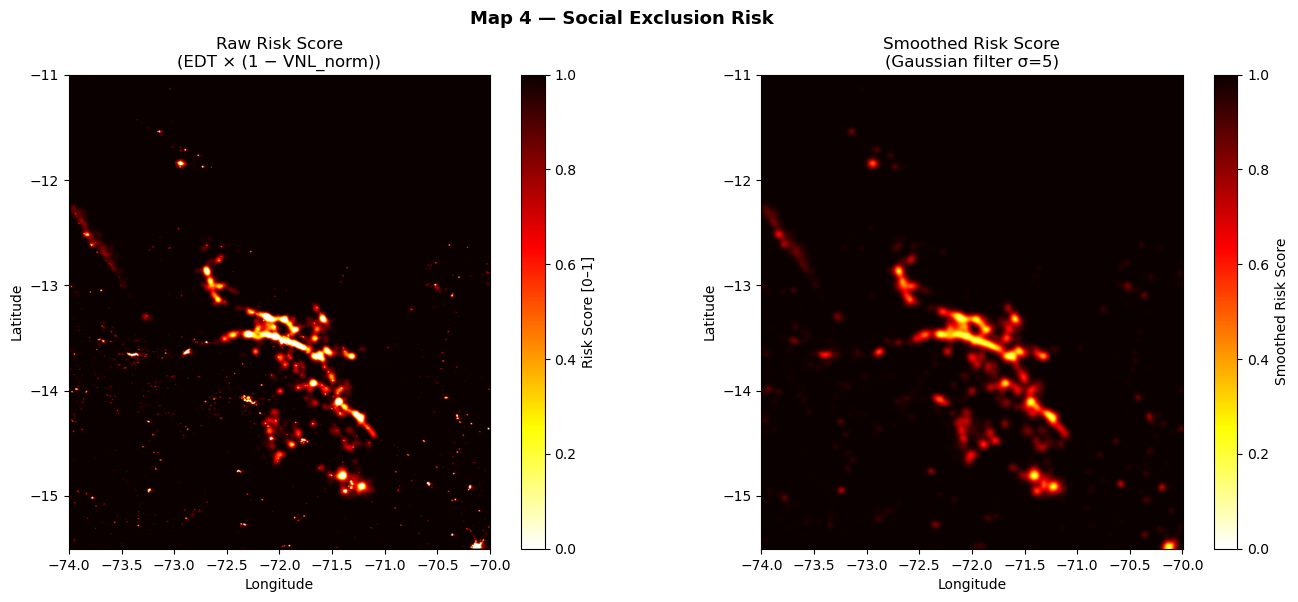

In [8]:
# Step 7 — Map 4: Social Exclusion Risk

# --- Calcular Risk score ---
risk_raw = EDT * (1 - vnl_norm)

# Normalizar a [0, 1]
risk_min = risk_raw.min()
risk_max = risk_raw.max()
risk_norm = (risk_raw - risk_min) / (risk_max - risk_min)

# Aplicar filtro Gaussiano (sigma=5)
risk_smooth = gaussian_filter(risk_norm, sigma=5)

# --- Percentiles ---
p75 = np.percentile(risk_norm, 75)
p90 = np.percentile(risk_norm, 90)
print(f"📊 Risk thresholds:")
print(f"   75th percentile: {p75:.4f}")
print(f"   90th percentile: {p90:.4f}")

# --- Mapa ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Map 4 — Social Exclusion Risk", fontsize=13, fontweight='bold')

# Panel izquierdo: riesgo crudo
ax = axes[0]
im0 = ax.imshow(risk_norm, cmap='hot_r', extent=extent,
                origin='upper', vmin=0, vmax=1)
plt.colorbar(im0, ax=ax, label='Risk Score [0–1]')
ax.set_title('Raw Risk Score\n(EDT × (1 − VNL_norm))')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Panel derecho: riesgo suavizado
ax = axes[1]
im1 = ax.imshow(risk_smooth, cmap='hot_r', extent=extent,
                origin='upper', vmin=0, vmax=risk_smooth.max())
plt.colorbar(im1, ax=ax, label='Smoothed Risk Score')
ax.set_title('Smoothed Risk Score\n(Gaussian filter σ=5)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig("../output/map4_risk.png", dpi=150, bbox_inches='tight')
plt.show()

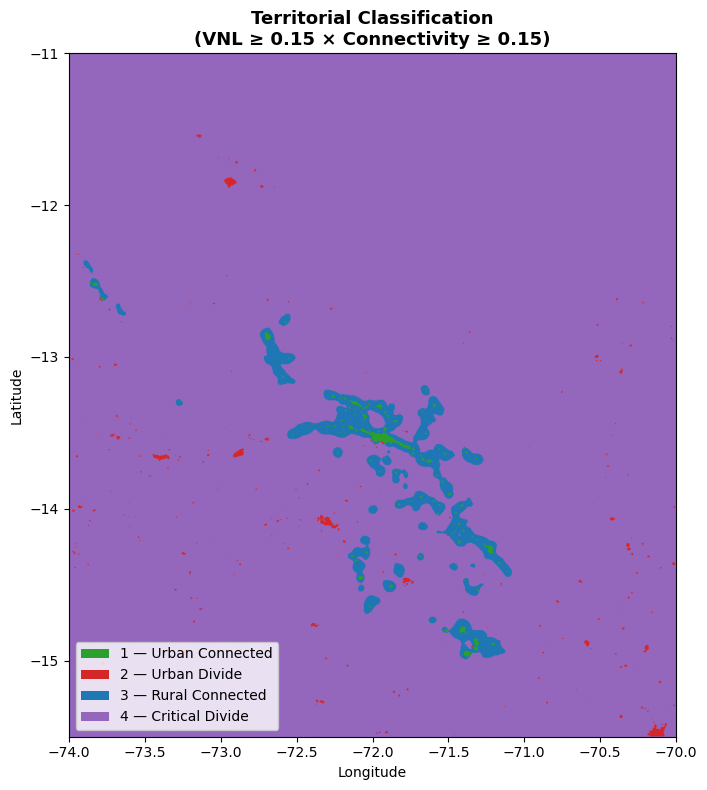


📊 Territorial Classification Summary:
Class                         Pixels        %     Area km²
---------------------------------------------------------
1 — Urban Connected            2,098    0.20%       448.8
2 — Urban Divide               2,856    0.27%       610.9
3 — Rural Connected           26,545    2.56%      5678.1
4 — Critical Divide        1,007,342   96.97%    215476.8

✅ Raster guardado en output/clasificacion_brecha.tif

              Class  Pixels     %  Area_km2
1 — Urban Connected    2098  0.20     448.8
   2 — Urban Divide    2856  0.27     610.9
3 — Rural Connected   26545  2.56    5678.1
4 — Critical Divide 1007342 96.97  215476.8


In [9]:
# Step 8 — Territorial Classification

# --- Clasificación 2x2 con umbrales VNL >= 0.15 y Connectivity >= 0.15 ---
classification = np.zeros(vnl_norm.shape, dtype=np.uint8)

vnl_high  = vnl_norm  >= 0.15
conn_high = conn_norm >= 0.15

# Clase 1: Urban Connected   (VNL alto, Conn alto)
classification[ vnl_high &  conn_high] = 1
# Clase 2: Urban Divide      (VNL alto, Conn bajo)
classification[ vnl_high & ~conn_high] = 2
# Clase 3: Rural Connected   (VNL bajo, Conn alto)
classification[~vnl_high &  conn_high] = 3
# Clase 4: Critical Divide   (VNL bajo, Conn bajo)
classification[~vnl_high & ~conn_high] = 4

# --- Mapa ---
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch

class_colors = ['#2ca02c', '#d62728', '#1f77b4', '#9467bd']
class_labels = ['1 — Urban Connected', '2 — Urban Divide',
                '3 — Rural Connected', '4 — Critical Divide']

cmap_class = ListedColormap(class_colors)
bounds_cls = [0.5, 1.5, 2.5, 3.5, 4.5]
norm_cls   = BoundaryNorm(bounds_cls, cmap_class.N)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(classification, cmap=cmap_class, norm=norm_cls,
               extent=extent, origin='upper')
ax.set_title('Territorial Classification\n(VNL ≥ 0.15 × Connectivity ≥ 0.15)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

legend_elements = [Patch(facecolor=class_colors[i], label=class_labels[i])
                   for i in range(4)]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig("../output/map5_classification.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Tabla resumen ---
pixel_size_km2 = (0.0041666667 * 111) ** 2  # grados → km²
total_pixels   = classification.size

print(f"\n📊 Territorial Classification Summary:")
print(f"{'Class':<25} {'Pixels':>10} {'%':>8} {'Area km²':>12}")
print("-" * 57)

rows = []
for i, label in enumerate(class_labels):
    cls   = i + 1
    count = int(np.sum(classification == cls))
    pct   = count / total_pixels * 100
    area  = count * pixel_size_km2
    rows.append({'Class': label, 'Pixels': count, '%': round(pct,2), 'Area_km2': round(area,1)})
    print(f"{label:<25} {count:>10,} {pct:>7.2f}% {area:>11.1f}")

df_class = pd.DataFrame(rows)

# --- Guardar raster de clasificación ---
with rasterio.open(VNL_PATH) as src:
    profile = src.profile.copy()

profile.update(dtype=rasterio.uint8, count=1, nodata=0)
with rasterio.open("../output/clasificacion_brecha.tif", 'w', **profile) as dst:
    dst.write(classification, 1)

print(f"\n✅ Raster guardado en output/clasificacion_brecha.tif")
print(f"\n{df_class.to_string(index=False)}")

📊 Descriptive Statistics by Class:

  1 — Urban Connected
                      mean      std      min      max
  VNL               0.5703   0.3039   0.1812   1.0000
  Connectivity      0.8283   0.2736   0.1565   1.0000
  IBD              -0.2580   0.3764  -0.8188   0.8435

  2 — Urban Divide
                      mean      std      min      max
  VNL               0.5330   0.3333   0.1589   1.0000
  Connectivity      0.0140   0.0359   0.0000   0.1337
  IBD               0.5190   0.3397   0.0308   1.0000

  3 — Rural Connected
                      mean      std      min      max
  VNL               0.0128   0.0237   0.0000   0.1431
  Connectivity      0.3963   0.2451   0.1502   1.0000
  IBD              -0.3835   0.2367  -1.0000  -0.0598

  4 — Critical Divide
                      mean      std      min      max
  VNL               0.0009   0.0070   0.0000   0.1470
  Connectivity      0.0031   0.0156   0.0000   0.1495
  IBD              -0.0022   0.0168  -0.1495   0.1470

📈 Pearson C

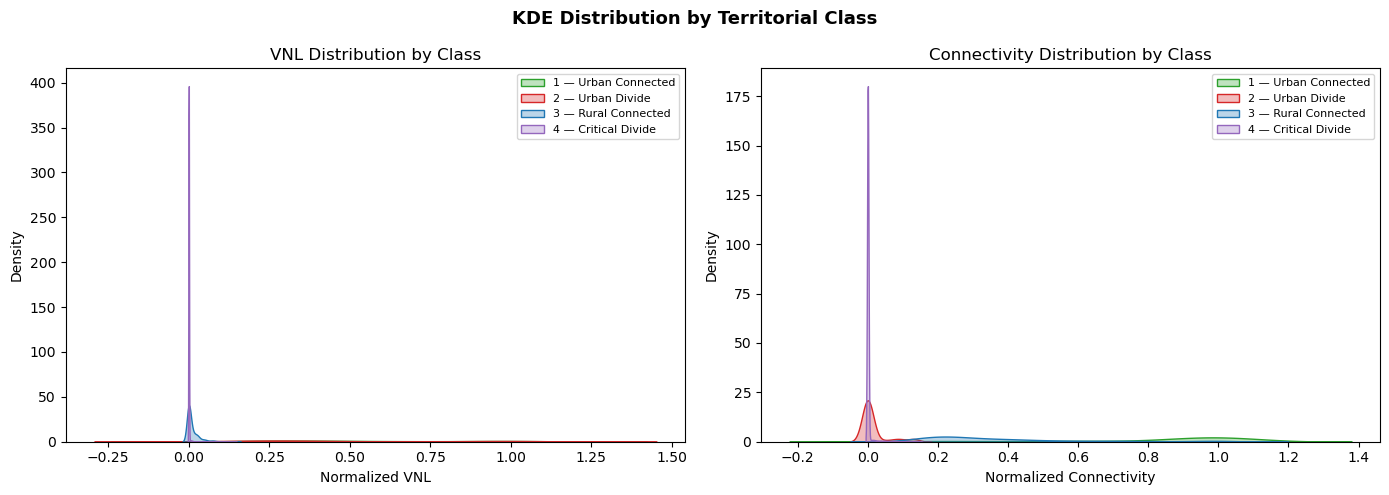


📐 Welch's t-test — Class 1 (Urban Connected) vs Class 4 (Critical Divide):
   t-statistic : 12.9809
   p-value     : 2.5682e-17
   Cohen's d   : 2.6490
   Interpretation: Significant difference ✅


In [10]:
# Step 9 — Statistical Summary

from scipy import stats as sp_stats

# --- Submuestra cada 40 píxeles para correlación ---
vnl_flat   = vnl_norm.flatten()[::40]
conn_flat  = conn_norm.flatten()[::40]
ibd_flat   = IBD.flatten()[::40]
class_flat = classification.flatten()[::40]

# --- 1. Estadísticas descriptivas por clase ---
print("📊 Descriptive Statistics by Class:")
print("="*65)
for i, label in enumerate(class_labels):
    cls  = i + 1
    mask = class_flat == cls
    if mask.sum() == 0:
        continue
    v = vnl_flat[mask]
    c = conn_flat[mask]
    b = ibd_flat[mask]
    print(f"\n  {label}")
    print(f"  {'':15} {'mean':>8} {'std':>8} {'min':>8} {'max':>8}")
    print(f"  {'VNL':15} {v.mean():>8.4f} {v.std():>8.4f} {v.min():>8.4f} {v.max():>8.4f}")
    print(f"  {'Connectivity':15} {c.mean():>8.4f} {c.std():>8.4f} {c.min():>8.4f} {c.max():>8.4f}")
    print(f"  {'IBD':15} {b.mean():>8.4f} {b.std():>8.4f} {b.min():>8.4f} {b.max():>8.4f}")

# --- 2. Correlación de Pearson VNL vs Connectivity ---
r, p_val = sp_stats.pearsonr(vnl_flat, conn_flat)
print(f"\n📈 Pearson Correlation (VNL vs Connectivity, every 40th pixel):")
print(f"   r = {r:.4f},  p-value = {p_val:.4e}")

# --- 3. KDE plots por clase ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("KDE Distribution by Territorial Class", fontsize=13, fontweight='bold')

colors_kde = ['#2ca02c', '#d62728', '#1f77b4', '#9467bd']

for i, label in enumerate(class_labels):
    cls  = i + 1
    mask = class_flat == cls
    if mask.sum() < 10:
        continue
    sns.kdeplot(vnl_flat[mask],   ax=axes[0], label=label,
                color=colors_kde[i], fill=True, alpha=0.3)
    sns.kdeplot(conn_flat[mask],  ax=axes[1], label=label,
                color=colors_kde[i], fill=True, alpha=0.3)

axes[0].set_title('VNL Distribution by Class')
axes[0].set_xlabel('Normalized VNL')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

axes[1].set_title('Connectivity Distribution by Class')
axes[1].set_xlabel('Normalized Connectivity')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../output/kde_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

# --- 4. Welch t-test: Clase 1 vs Clase 4 ---
mask1 = class_flat == 1
mask4 = class_flat == 4

vnl_c1 = vnl_flat[mask1]
vnl_c4 = vnl_flat[mask4]

t_stat, p_welch = sp_stats.ttest_ind(vnl_c1, vnl_c4, equal_var=False)

# Cohen's d
pooled_std = np.sqrt((vnl_c1.std()**2 + vnl_c4.std()**2) / 2)
cohens_d   = (vnl_c1.mean() - vnl_c4.mean()) / pooled_std

print(f"\n📐 Welch's t-test — Class 1 (Urban Connected) vs Class 4 (Critical Divide):")
print(f"   t-statistic : {t_stat:.4f}")
print(f"   p-value     : {p_welch:.4e}")
print(f"   Cohen's d   : {cohens_d:.4f}")
print(f"   Interpretation: {'Significant difference ✅' if p_welch < 0.05 else 'No significant difference ❌'}")

💾 Exportando rasters...
  ✅ Guardado: ../output/vnl_norm.tif
  ✅ Guardado: ../output/conn_norm.tif
  ✅ Guardado: ../output/ibd_brecha_digital.tif
  ✅ Guardado: ../output/clasificacion_brecha.tif

🖼️  Generando dashboard final...


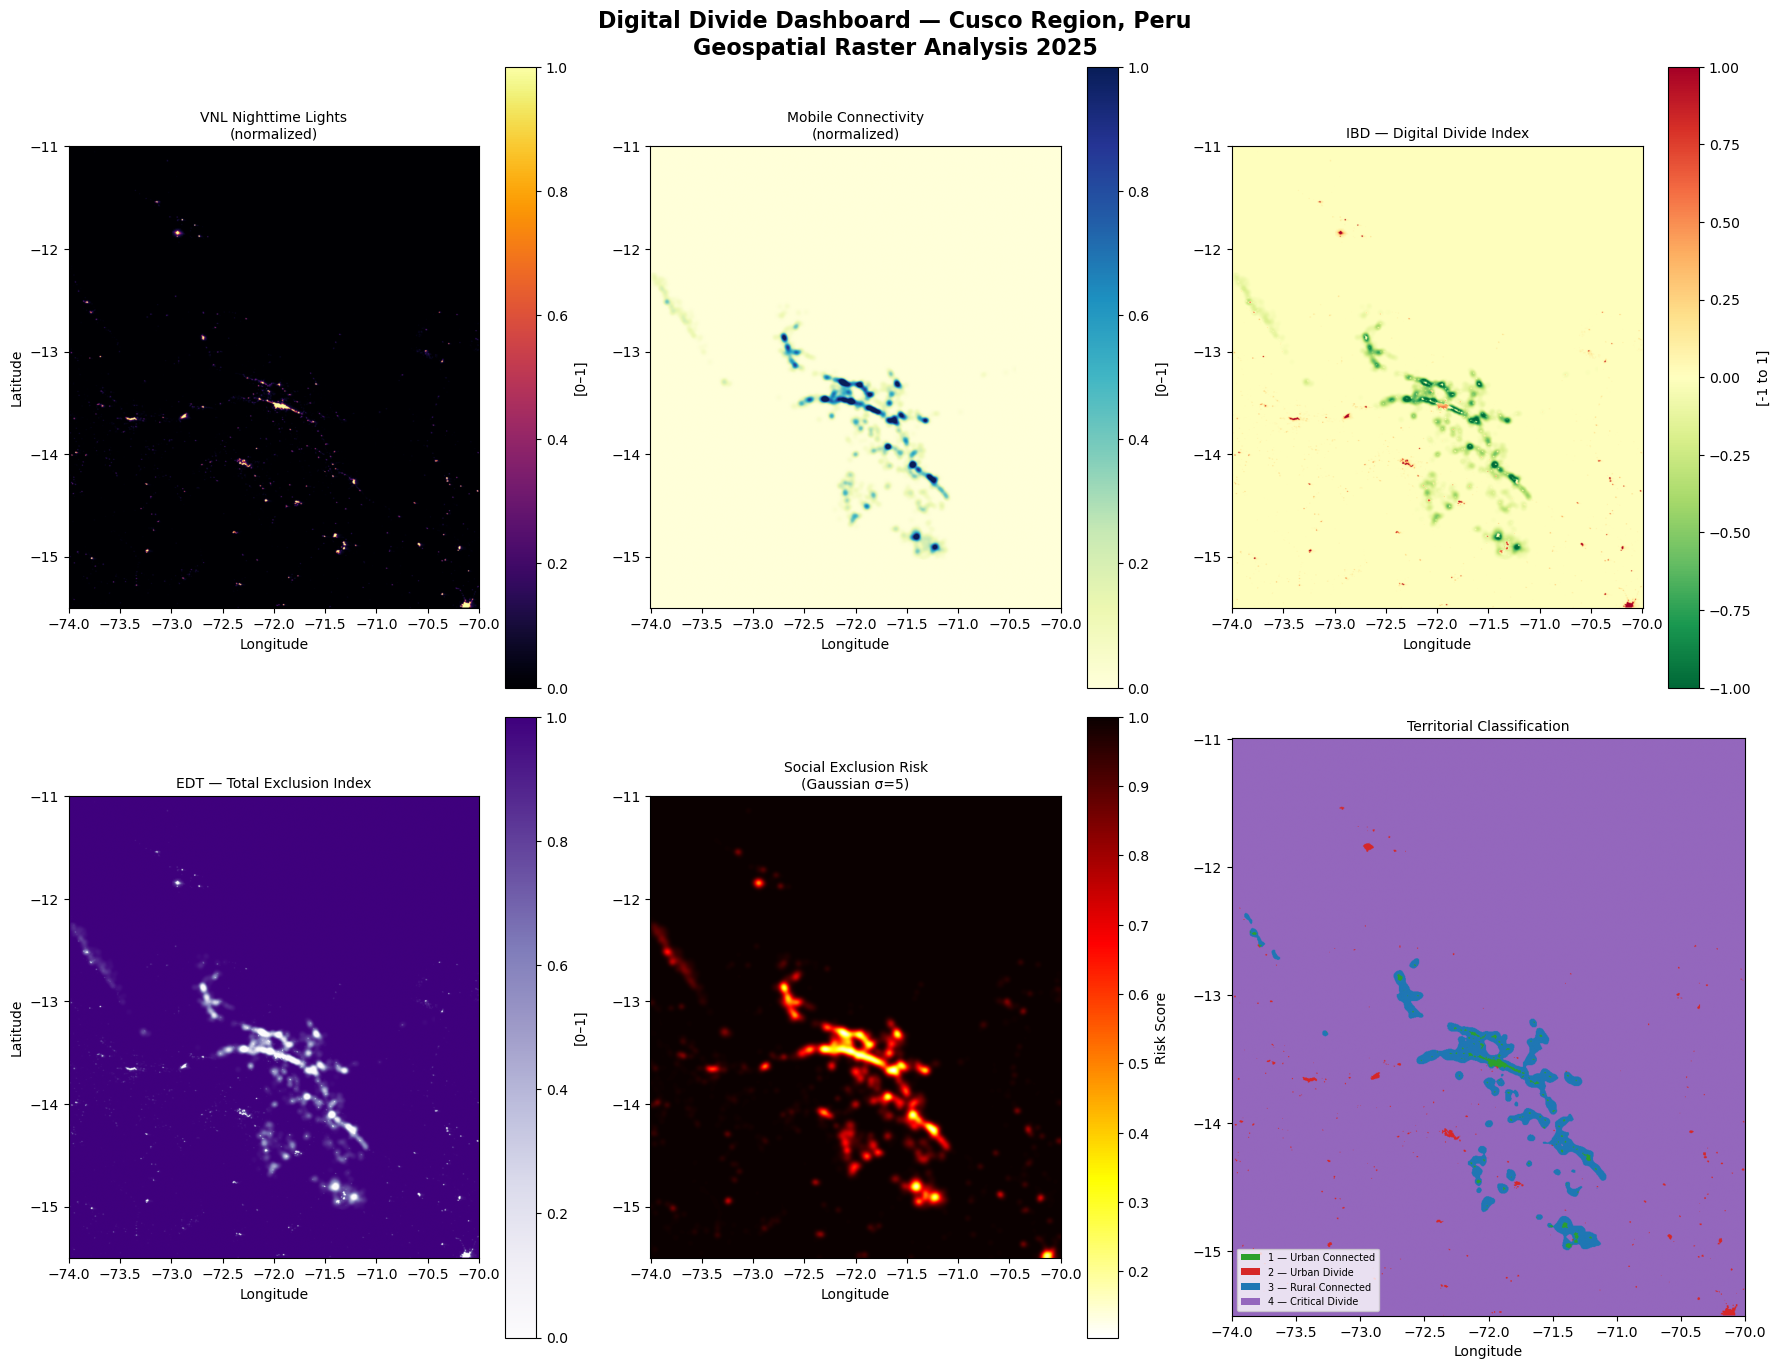

✅ Dashboard guardado en output/dashboard_brecha_digital.png


In [11]:
# Step 10 — Export Deliverables

def save_raster(array, reference_path, output_path, dtype=rasterio.float32):
    with rasterio.open(reference_path) as src:
        profile = src.profile.copy()
    profile.update(dtype=dtype, count=1, nodata=0)
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(array.astype(dtype), 1)
    print(f"  ✅ Guardado: {output_path}")

print("💾 Exportando rasters...")
save_raster(vnl_norm,        VNL_PATH, "../output/vnl_norm.tif")
save_raster(conn_norm,       VNL_PATH, "../output/conn_norm.tif")
save_raster(IBD,             VNL_PATH, "../output/ibd_brecha_digital.tif")
save_raster(classification,  VNL_PATH, "../output/clasificacion_brecha.tif",
            dtype=rasterio.uint8)

# --- Dashboard Final ---
print("\n🖼️  Generando dashboard final...")

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Digital Divide Dashboard — Cusco Region, Peru\nGeospatial Raster Analysis 2025",
             fontsize=16, fontweight='bold', y=0.98)

# Layout: 2 filas x 3 columnas
ax1 = fig.add_subplot(2, 3, 1)
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)
ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, 5)
ax6 = fig.add_subplot(2, 3, 6)

# 1 — VNL normalizado
im1 = ax1.imshow(vnl_norm, cmap='inferno', extent=extent, origin='upper')
plt.colorbar(im1, ax=ax1, label='[0–1]')
ax1.set_title('VNL Nighttime Lights\n(normalized)', fontsize=10)
ax1.set_xlabel('Longitude'); ax1.set_ylabel('Latitude')

# 2 — Connectivity normalizado
im2 = ax2.imshow(conn_norm, cmap='YlGnBu', extent=extent, origin='upper')
plt.colorbar(im2, ax=ax2, label='[0–1]')
ax2.set_title('Mobile Connectivity\n(normalized)', fontsize=10)
ax2.set_xlabel('Longitude')

# 3 — IBD
im3 = ax3.imshow(IBD, cmap='RdYlGn_r', extent=extent,
                 origin='upper', vmin=-1, vmax=1)
plt.colorbar(im3, ax=ax3, label='[-1 to 1]')
ax3.set_title('IBD — Digital Divide Index', fontsize=10)
ax3.set_xlabel('Longitude')

# 4 — EDT
im4 = ax4.imshow(EDT, cmap='Purples', extent=extent, origin='upper')
plt.colorbar(im4, ax=ax4, label='[0–1]')
ax4.set_title('EDT — Total Exclusion Index', fontsize=10)
ax4.set_xlabel('Longitude'); ax4.set_ylabel('Latitude')

# 5 — Risk suavizado
im5 = ax5.imshow(risk_smooth, cmap='hot_r', extent=extent, origin='upper')
plt.colorbar(im5, ax=ax5, label='Risk Score')
ax5.set_title('Social Exclusion Risk\n(Gaussian σ=5)', fontsize=10)
ax5.set_xlabel('Longitude')

# 6 — Clasificación
im6 = ax6.imshow(classification, cmap=cmap_class, norm=norm_cls,
                 extent=extent, origin='upper')
legend_elements = [Patch(facecolor=class_colors[i], label=class_labels[i])
                   for i in range(4)]
ax6.legend(handles=legend_elements, loc='lower left', fontsize=7)
ax6.set_title('Territorial Classification', fontsize=10)
ax6.set_xlabel('Longitude')

plt.tight_layout()
plt.savefig("../output/dashboard_brecha_digital.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard guardado en output/dashboard_brecha_digital.png")